# QSVT
----

## 数学原理

### 1. 从 QSP 到 QSVT
上一节 QSP 的核心是
$$
x\mapsto P(x)
$$
但真正的问题通常不是标量, 而是矩阵 $A$. 于是问题变成了
> 能否将 $x\mapsto P(x)$ 推广为矩阵变换

对于 Hermitian matrix, 最直观的是
$$
A=\sum_j \lambda_j\ket{u_j}\bra{u_j}
$$
我们希望
$$
A\mapsto P(A)=\sum_j P(\lambda_j)\ket{u_j}\bra{u_j}
$$
而对于一般的 non-Hermitian matrix, 连 eigenvalue decomposition 都无法保证.

### 2. Singular Value Decomposition (SVD)
任意矩阵可以写成
$$
A=\sum_j \sigma_j\ket{u_j}\bra{v_j}
$$
也就是
$$
A=U\Sigma V^\dagger
$$
其中 $\sigma_j\geq 0$ 是矩阵的奇异值. 并且满足
$$
A\ket{v_j}=\sigma_j\ket{u_j},\quad A^\dagger\ket{u_j}=\sigma_j\ket{v_j}
$$
所以 QSVT 的目标不再是
$$
\lambda_j\mapsto P(\lambda_j)
$$
而是
$$
\sigma_j\mapsto P(\sigma_j)
$$

### 3. 奇 QSVT 变换
对于适合的奇多项式
$$
P(-x)=-P(x)
$$
QSVT 对于
$$
A=\sum_j \sigma_j \ket{u_j}\bra{v_j}
$$
产生
$$
P^{(SV)}(A)=\sum_j P(\sigma_j)\ket{u_j}\bra{v_j}
$$
注意一般不是 $P(A)$. 对于 non-Hermitian 的矩阵, 通常成立
$$
P^{(SV)}(A)\neq P(A)
$$

### 4. 为什么奇偶性再次出现
可以用 Hermitian dilation 来理解. 定义
$$
\mathcal{H}_A=\begin{bmatrix}
0 & A \\
A^\dagger & 0
\end{bmatrix}
$$
和
$$
\ket{L_j}=\begin{bmatrix}
\ket{u_j}\\
0
\end{bmatrix},\quad \ket{R_j}=\begin{bmatrix}
0\\
\ket{v_j}
\end{bmatrix}
$$
则有
$$
\mathcal{H}_A\ket{L_j}=\sigma\ket{R_j},\quad \mathcal{H}_A\ket{R_j}=\sigma\ket{L_j}
$$
所以在二维子空间 $span\{\ket{L_j},\ket{R_j}\}$ 中, 有
$$
\mathcal{H}_A\sim \sigma_j X
$$
其本征值为 $\pm\sigma_j$, 于是 QSVT 变为 QSP 问题.

### 5. 本节统一实验
选择矩阵
$$
A=\begin{bmatrix}
1 & 0 \\
0 & 0.5
\end{bmatrix}
$$
其奇异值为 $\sigma_1=1,\sigma_2=0.5$,并且 $\|A\|=1$. 条件数为 
$$
\kappa=\frac{\sigma_{max}}{\sigma_{min}}=2
$$

### 6. 第一个 QSVT 实验: $p(x)=x^3$
先选择一个简单的多项式
$$
P(x)=x^3
$$
则有
$$
\sigma_1=1\to P(\sigma_1)=1,\qquad \sigma_2=0.5\to P(\sigma_2)=0.125
$$
所以矩阵 A 经过 QSVT 后应变为
$$
P(A)=\begin{bmatrix}
1 & 0 \\
0 & 0.125
\end{bmatrix}
$$

In [1]:
# 官方实现
import numpy as np
from unitarylab.library import QSVT

%matplotlib inline

A = np.array([[1.0, 0.0], [0.0, 0.5]], dtype=complex)


def cubic_function(x):
    """目标函数"""
    return x**3


qsvt = QSVT(
    A,
    function=cubic_function,
    target_error=1e-6,
    block_encoding_method="nagy",
    device="cpu",
)

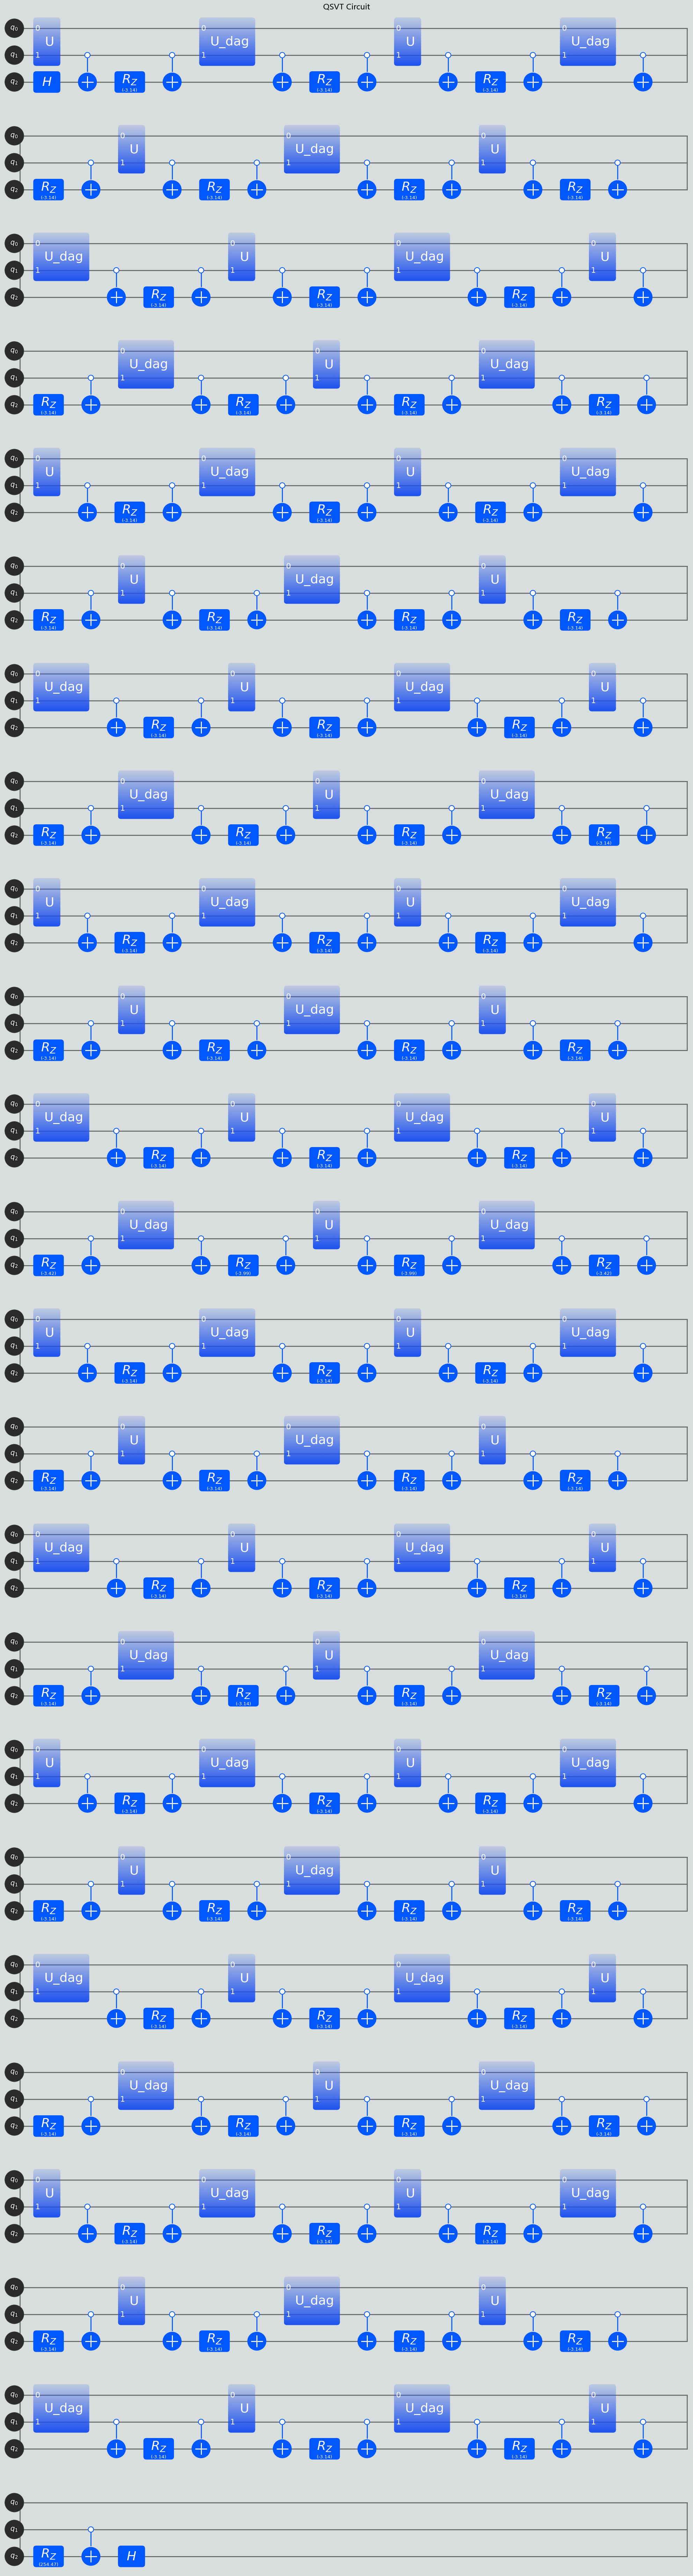

In [3]:
# 绘制线路
qsvt_circuit = qsvt.circuit
_ = qsvt_circuit.draw(title="QSVT Circuit")

In [4]:
# 读取基本元素
print("QSVT degree =", qsvt.degree)
print("Block-encoding alpha =", qsvt.alpha)
print("Ancilla count m =", qsvt.m)
print("Official QSVT error =", qsvt.total_error)

QSVT degree = 81
Block-encoding alpha = 1.0
Ancilla count m = 1
Official QSVT error = 8.486544800591985e-13


In [5]:
# 官方输出矩阵
official_qsvt_matrix = np.asarray(qsvt.evolution_result)

# 理论输出矩阵
expected_cubic = A @ A @ A

# 打印检查
print("Expected A^3 =\n", expected_cubic)
print("Official QSVT =\n", official_qsvt_matrix)

Expected A^3 =
 [[1.   +0.j 0.   +0.j]
 [0.   +0.j 0.125+0.j]]
Official QSVT =
 [[1.00000000e+00+0.j 0.00000000e+00+0.j]
 [7.65404249e-18+0.j 1.25000000e-01+0.j]]


In [6]:
# 手写 QSVT
def singular_value_transfrom(matrix, function):
    U, singular_values, Vh = np.linalg.svd(matrix)
    transformed_values = function(singular_values)

    return U @ np.diag(transformed_values) @ Vh


manual_qsvt_matrix = singular_value_transfrom(A, lambda x: x**3)

print("Manual QSVT =\n", manual_qsvt_matrix)

Manual QSVT =
 [[1.   +0.j 0.   +0.j]
 [0.   +0.j 0.125+0.j]]


In [7]:
# 手写对比官方
manual_qsvt_error = np.linalg.norm(manual_qsvt_matrix - expected_cubic)
official_vs_manual = np.linalg.norm(official_qsvt_matrix - manual_qsvt_matrix)

print("Manual error =", manual_qsvt_error)
print("Official vs Manual =", official_vs_manual)

Manual error = 0.0
Official vs Manual = 8.629386999439121e-13


### 1. 现在考虑线性系统
考虑线性系统
$$
Ax=b
$$
若 $A=U\Sigma V^\dagger$, 则有
$$
A^{-1}=V\Sigma^{-1}U^\dagger
$$
所以
$$
A^{-1}:\sigma_j\to \frac{1}{\sigma_j}
$$
这就是一个 singular value transform.

### 2. 为什么不能直接选择 $P(x)=1/x$?
因为